In [110]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict,Literal
from pydantic import Field,BaseModel

In [111]:
load_dotenv()

True

In [112]:
llm=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7
)

In [113]:
class Sentiment(BaseModel):
    Sentiment:Literal["positive","negative"]=Field(description='sentiment to the review')

In [114]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [115]:
structure_llm=llm.with_structured_output(Sentiment)
structure_llm1=llm.with_structured_output(DiagnosisSchema)

In [116]:
prompt1="what is the sentiment of followin reveiw-we want to become a billanior "
structure_llm.invoke(prompt1).Sentiment 

'positive'

In [117]:
class reviewstate(TypedDict):
    review:str
    Sentiment:Literal['positive','negative']
    diagnosis:dict
    response:str

In [118]:
def findreview(state:reviewstate):
    prompt=f'for the followin reveiw find out the sentiment/n{state['review']}'
    Sentiment=structure_llm.invoke(prompt)

    return {'Sentiment':Sentiment}

def check_sentiment(state:reviewstate)-> Literal['positive_response','run_diagnosis']:
    if state['Sentiment']=='positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state:reviewstate):
    
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    
    response = llm.invoke(prompt).content

    return {'response': response}
def run_diagnosis(state: reviewstate):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structure_llm1.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: reviewstate):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = llm.invoke(prompt).content

    return {'response': response}

In [119]:
graph=StateGraph(reviewstate)
graph.add_node('findreview',findreview)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_edge(START,'findreview')
graph.add_conditional_edges('findreview',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
workflow=graph.compile()

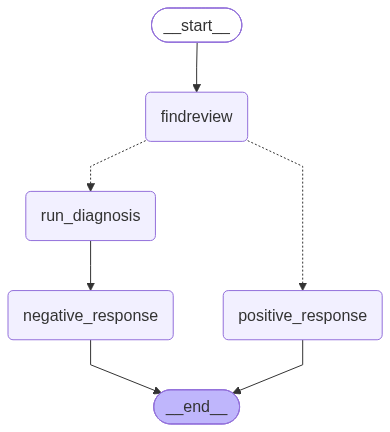

In [120]:
workflow

In [121]:
intial_state={
 "review":'we are become a billanior'
}

workflow.invoke(intial_state)

{'review': 'we are become a billanior',
 'Sentiment': Sentiment(Sentiment='positive'),
 'diagnosis': {'issue_type': 'Other', 'tone': 'calm', 'urgency': 'low'},
 'response': "I'm glad you reached out to us for assistance with the issue you're experiencing. I can imagine it might be frustrating when things don't go as planned, but I'm here to help you resolve it. \n\nSince you've marked the urgency as low, we can take our time to thoroughly understand and address the problem. I'd like to start by gathering a bit more information about what's happening. Could you please provide me with some more details about the issue you're facing? This will help me better understand the situation and provide a more accurate solution.\n\nIn the meantime, I want to assure you that we're committed to helping you find a resolution. We'll work together to identify the cause and find a suitable fix. If there's anything I can do to make this process smoother for you, please don't hesitate to let me know.\n\nT